# Queries for NP-1

derived from the file queries.ipnyb

In [1]:
import pickle
import sys
import os

# 1. the folder containing the parser, in this case Raha Musavi's parser
parser_path = r"C:\Users\rahaa\Dropbox\MPCD\syntax_project\mp-corpus-parser"

# 2. Add the parser folder to Python's search path
if parser_path not in sys.path:
    sys.path.append(parser_path)

# 3. Imports the classes from the parser
from rm_mptf_parser import Sentence, Token

# 4. Path to the actual pickle file
pkl_file_path = r"C:\Users\rahaa\Dropbox\MPCD\syntax_project\corpus\annotated_corpus.pkl"

# 5. Load the corpus
try:
    with open(pkl_file_path, 'rb') as f:
        annotated_corpus = pickle.load(f)
    print(f"Success! Loaded {len(annotated_corpus)} annotated sentences.")
except FileNotFoundError:
    print(f"Error: Could not find the file at {pkl_file_path}")
except Exception as e:
    print(f"An error occurred: {e}")

Success! Loaded 42255 annotated sentences.


In [2]:
from collections import defaultdict

np_head_deprels = [
    "nmod", "nsubj", "obj", "obl",
    "iobj", "vocative", "dislocated",
    "appos", "flat"
]

def get_base_deprel(deprel):
    if not deprel:
        return None
    return deprel.split(":")[0]


def compute_np_head_stats(corpus):
    # global counts
    global_counts = defaultdict(int)
    total_np_heads = 0

    # per-file counts
    per_file_counts = defaultdict(lambda: defaultdict(int))
    per_file_totals = defaultdict(int)

    for sent in corpus:
        file_name = sent.file_name

        for tok in sent.get_tokens():
            base = get_base_deprel(tok.deprel)

            if base in np_head_deprels:
                global_counts[base] += 1
                per_file_counts[file_name][base] += 1

                total_np_heads += 1
                per_file_totals[file_name] += 1

    # =========================
    # GLOBAL RESULTS
    # =========================
    print("\n=== GLOBAL NP HEAD DEPRELS ===")
    for dep in np_head_deprels:
        count = global_counts[dep]
        perc = (count / total_np_heads * 100) if total_np_heads > 0 else 0
        print(f"{dep:12} | count={count:6} | {perc:6.2f}%")

    print(f"\nTotal NP-head tokens: {total_np_heads}")

    # =========================
    # PER-FILE RESULTS
    # =========================
    print("\n=== PER FILE STATS ===")
    for file_name in per_file_counts:
        print(f"\n--- {file_name} ---")
        file_total = per_file_totals[file_name]

        for dep in np_head_deprels:
            count = per_file_counts[file_name][dep]
            perc = (count / file_total * 100) if file_total > 0 else 0
            print(f"{dep:12} | count={count:6} | {perc:6.2f}%")

        print(f"Total NP-head tokens: {file_total}")
    
# Run the analysis
compute_np_head_stats(annotated_corpus)


=== GLOBAL NP HEAD DEPRELS ===
nmod         | count=  5950 |  26.26%
nsubj        | count=  5750 |  25.38%
obj          | count=  2657 |  11.73%
obl          | count=  6874 |  30.34%
iobj         | count=    97 |   0.43%
vocative     | count=   130 |   0.57%
dislocated   | count=   511 |   2.26%
appos        | count=   515 |   2.27%
flat         | count=   172 |   0.76%

Total NP-head tokens: 22656

=== PER FILE STATS ===

--- AOD-K20 ---
nmod         | count=    33 |  17.10%
nsubj        | count=    61 |  31.61%
obj          | count=    27 |  13.99%
obl          | count=    65 |  33.68%
iobj         | count=     1 |   0.52%
vocative     | count=     0 |   0.00%
dislocated   | count=     6 |   3.11%
appos        | count=     0 |   0.00%
flat         | count=     0 |   0.00%
Total NP-head tokens: 193

--- Col-TD1-1 ---
nmod         | count=    10 |  26.32%
nsubj        | count=     9 |  23.68%
obj          | count=     2 |   5.26%
obl          | count=     2 |   5.26%
iobj         | co

In [3]:
from collections import defaultdict

np_head_deprels = [
    "nmod", "nsubj", "obj", "obl",
    "iobj", "vocative", "dislocated",
    "appos", "flat"
]

def normalize_deprel(deprel):
    """Take first deprel if '|' exists"""
    if not deprel:
        return None
    return deprel.split("|")[0].strip()

def is_cl_variant(deprel):
    """Exclude clausal variants like apposcl, nsubjcl, etc."""
    if not deprel:
        return False
    base = deprel.split(":")[0]  # ignore subtypes like obl:emph

    return base.endswith("cl")


def is_np_head(deprel):
    """Check NP-head match + exclude cl variants"""
    if not deprel:
        return False

    if is_cl_variant(deprel):
        return False

    return any(deprel.startswith(prefix) for prefix in np_head_deprels)


def compute_np_head_stats(corpus):
    global_counts = defaultdict(int)
    total_np_heads = 0

    per_file_counts = defaultdict(lambda: defaultdict(int))
    per_file_totals = defaultdict(int)

    for sent in corpus:
        file_name = sent.file_name

        for tok in sent.get_tokens():
            dep = normalize_deprel(tok.deprel)

            if is_np_head(dep):
                global_counts[dep] += 1
                per_file_counts[file_name][dep] += 1

                total_np_heads += 1
                per_file_totals[file_name] += 1

    # =========================
    # GLOBAL RESULTS
    # =========================
    print("\n=== GLOBAL NP HEAD DEPRELS (NO *CL VARIANTS) ===")

    for dep, count in sorted(global_counts.items()):
        perc = (count / total_np_heads * 100) if total_np_heads > 0 else 0
        print(f"{dep:20} | count={count:6} | {perc:6.2f}%")

    print(f"\nTotal NP-head tokens (filtered): {total_np_heads}")

    # =========================
    # PER FILE RESULTS
    # =========================
    print("\n=== PER FILE STATS ===")

    for file_name in per_file_counts:
        print(f"\n--- {file_name} ---")
        file_total = per_file_totals[file_name]

        for dep, count in sorted(per_file_counts[file_name].items()):
            perc = (count / file_total * 100) if file_total > 0 else 0
            print(f"{dep:20} | count={count:6} | {perc:6.2f}%")

        print(f"Total NP-head tokens: {file_total}")


# Run
compute_np_head_stats(annotated_corpus)


=== GLOBAL NP HEAD DEPRELS (NO *CL VARIANTS) ===
appos                | count=   516 |   2.28%
dislocated           | count=    56 |   0.25%
dislocated:res       | count=   239 |   1.05%
dislocated:topic     | count=   216 |   0.95%
flat                 | count=   173 |   0.76%
iobj                 | count=    97 |   0.43%
nmod                 | count=  5942 |  26.21%
nmod:poss            | count=    16 |   0.07%
nsubj                | count=  5379 |  23.73%
nsubj:emph           | count=     8 |   0.04%
nsubj:outer          | count=    92 |   0.41%
nsubj:pass           | count=   272 |   1.20%
obj                  | count=  2658 |  11.72%
obj:emph             | count=     1 |   0.00%
obl                  | count=  6218 |  27.43%
obl:agent            | count=     5 |   0.02%
obl:emph             | count=     1 |   0.00%
obl:lmod             | count=   410 |   1.81%
obl:tmod             | count=   243 |   1.07%
vocative             | count=   130 |   0.57%

Total NP-head tokens (filtere

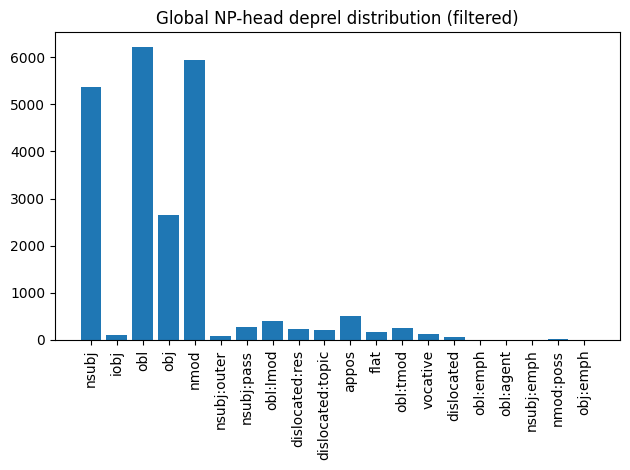

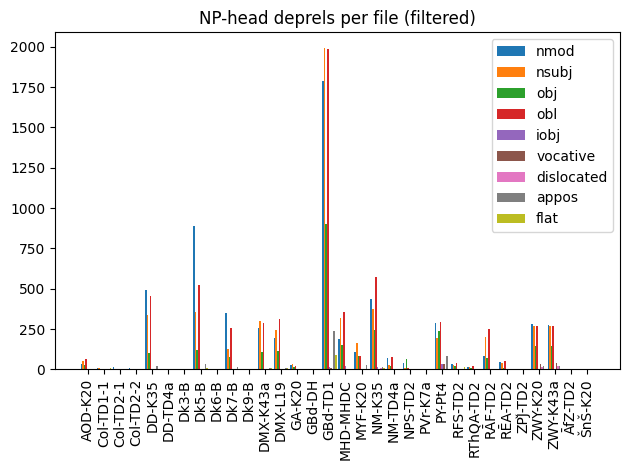

Total NP-head tokens: 22672


In [4]:
import matplotlib.pyplot as plt
from collections import defaultdict

np_head_deprels = [
    "nmod", "nsubj", "obj", "obl",
    "iobj", "vocative", "dislocated",
    "appos", "flat"
]

def normalize_deprel(deprel):
    if not deprel:
        return None
    return deprel.split("|")[0].strip()

def is_cl_variant(deprel):
    if not deprel:
        return False
    base = deprel.split(":")[0]
    return base.endswith("cl")

def is_np_head(deprel):
    if not deprel:
        return False
    if is_cl_variant(deprel):
        return False
    return any(deprel.startswith(prefix) for prefix in np_head_deprels)


def plot_np_head_stats(corpus):
    global_counts = defaultdict(int)
    per_file_counts = defaultdict(lambda: defaultdict(int))
    per_file_totals = defaultdict(int)
    total_np = 0

    # =========================
    # COLLECT DATA
    # =========================
    for sent in corpus:
        file_name = sent.file_name

        for tok in sent.get_tokens():
            dep = normalize_deprel(tok.deprel)

            if is_np_head(dep):
                global_counts[dep] += 1
                per_file_counts[file_name][dep] += 1

                total_np += 1
                per_file_totals[file_name] += 1

    # =========================
    # GLOBAL PLOT
    # =========================
    labels = list(global_counts.keys())
    values = [global_counts[l] for l in labels]

    plt.figure()
    plt.bar(labels, values)
    plt.title("Global NP-head deprel distribution (filtered)")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

    # =========================
    # PER FILE PLOT (GROUPED BAR)
    # =========================
    files = list(per_file_counts.keys())
    labels = np_head_deprels  # fixed order for comparability

    x = range(len(files))
    width = 0.1

    plt.figure()

    for i, dep in enumerate(labels):
        values = [per_file_counts[f][dep] for f in files]
        plt.bar([pos + i*width for pos in x], values, width, label=dep)

    plt.xticks([pos + width*4 for pos in x], files, rotation=90)
    plt.title("NP-head deprels per file (filtered)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Total NP-head tokens: {total_np}")

# Run the plotting function
plot_np_head_stats(annotated_corpus)

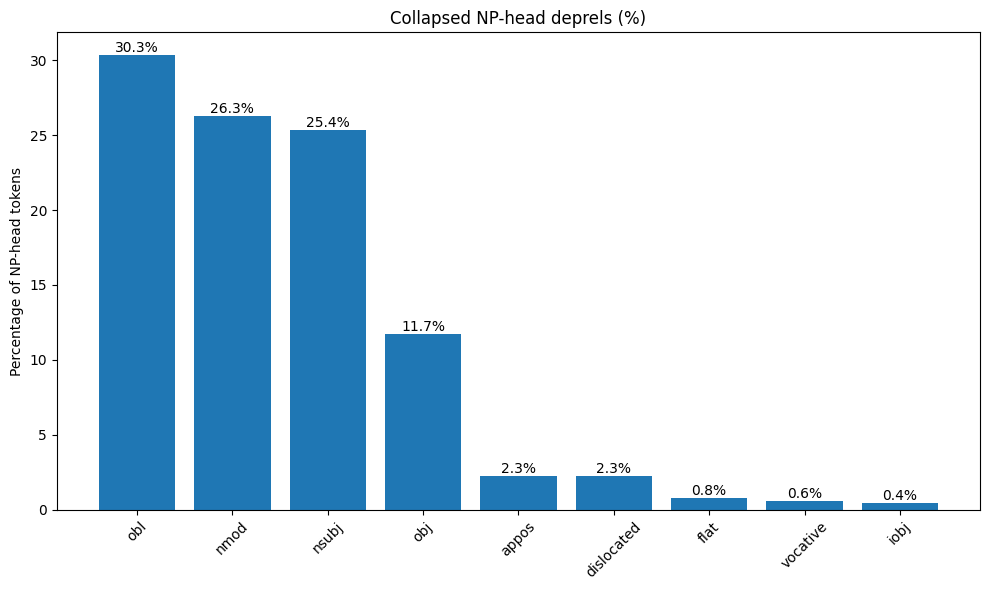

Total NP-head tokens: 22672


In [5]:
def plot_np_head_stats(corpus):
    global_counts = defaultdict(int)
    total_np = 0

    # =========================
    # COLLECT DATA
    # =========================
    for sent in corpus:
        for tok in sent.get_tokens():
            dep = normalize_deprel(tok.deprel)

            if is_np_head(dep):
                global_counts[dep] += 1
                total_np += 1

    # =========================
    # COLLAPSE SUBRELATIONS
    # =========================
    collapsed_counts = defaultdict(int)

    for dep, count in global_counts.items():
        base = dep.split(":")[0]
        collapsed_counts[base] += count

    # =========================
    # SORT BY SIZE
    # =========================
    sorted_items = sorted(
        collapsed_counts.items(),
        key=lambda x: x[1],
        reverse=True
    )

    labels = [item[0] for item in sorted_items]
    values = [item[1] for item in sorted_items]

    # percentages
    percentages = [
        (v / total_np) * 100
        for v in values
    ]

    # =========================
    # PLOT
    # =========================
    plt.figure(figsize=(10, 6))

    bars = plt.bar(labels, percentages)

    plt.ylabel("Percentage of NP-head tokens")
    plt.title("Collapsed NP-head deprels (%)")

    plt.xticks(rotation=45)

    # add percentage labels above bars
    for bar, pct in zip(bars, percentages):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{pct:.1f}%",
            ha='center',
            va='bottom'
        )

    plt.tight_layout()
    plt.show()

    print(f"Total NP-head tokens: {total_np}")

# Run
plot_np_head_stats(annotated_corpus)

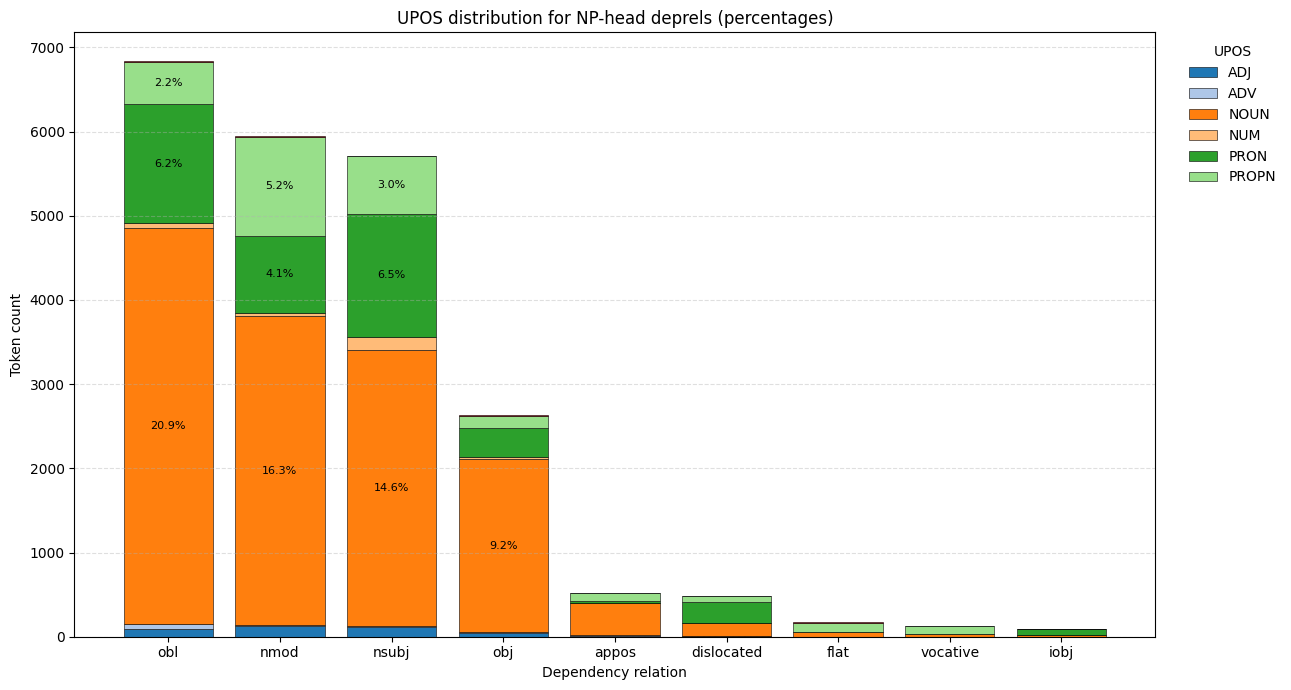

In [ ]:
def plot_np_head_upos_stacked(corpus):
    from collections import defaultdict
    import matplotlib.pyplot as plt
    import numpy as np

    target_deprels = np_head_deprels
    ignored_upos = {"ADP", "DET", "PART", "INTJ", "PUNCT", "SCONJ", "VERB"}

    counts = defaultdict(lambda: defaultdict(int))

    # =========================
    # COLLECT DATA
    # =========================
    for sent in corpus:
        for tok in sent.get_tokens():

            dep = normalize_deprel(tok.deprel)
            if not dep:
                continue

            dep_base = dep.split(":")[0]

            if dep_base in target_deprels:

                upos = tok.upos
                if upos in ignored_upos:
                    continue

                counts[dep_base][upos] += 1
    
    # =========================
    # TOTAL TOKENS (WHOLE CORPUS)
    # =========================
    total_all = sum(
        sum(upos_counts.values())
        for upos_counts in counts.values()
    )

    # =========================
    # SORT DEPRELS BY TOTAL SIZE
    # =========================
    deprel_totals = {
        dep: sum(counts[dep].values())
        for dep in target_deprels
    }

    total_all = sum(
    sum(upos_counts.values())
    for upos_counts in counts.values()
)
    
    target_deprels = sorted(
        target_deprels,
        key=lambda dep: deprel_totals[dep],
        reverse=True
    )

    # =========================
    # GET UPOS
    # =========================
    all_upos = sorted({
        upos
        for dep in target_deprels
        for upos in counts[dep]
    })

    x = np.arange(len(target_deprels))
    bottoms = np.zeros(len(target_deprels))

    cmap = plt.get_cmap("tab20")

    plt.figure(figsize=(13, 7))

    # store segment positions for annotations
    segment_positions = defaultdict(list)

    for i, upos in enumerate(all_upos):

        values = [counts[dep][upos] for dep in target_deprels]

        bars = plt.bar(
            x,
            values,
            bottom=bottoms,
            label=upos,
            color=cmap(i % 20),
            edgecolor="black",
            linewidth=0.4
        )

        # global percentages (whole corpus)
        for j, dep in enumerate(target_deprels):
            val = values[j]

            if val > 0:
                pct = 100 * val / total_all

                # ONLY show if > 2% of corpus
                if pct > 2:
                    plt.text(
                        x[j],
                        bottoms[j] + val / 2,
                        f"{pct:.1f}%",
                        ha='center',
                        va='center',
                        fontsize=8,
                        color='black'
                    )
        bottoms += values

    # =========================
    # FORMATTING
    # =========================
    plt.xticks(x, target_deprels, rotation=0)

    plt.ylabel("Token count")
    plt.xlabel("Dependency relation")
    plt.title("UPOS distribution for NP-head deprels (percentages)")

    plt.legend(
        title="UPOS",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False
    )

    plt.grid(axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()


# Run
plot_np_head_upos_stacked(annotated_corpus)

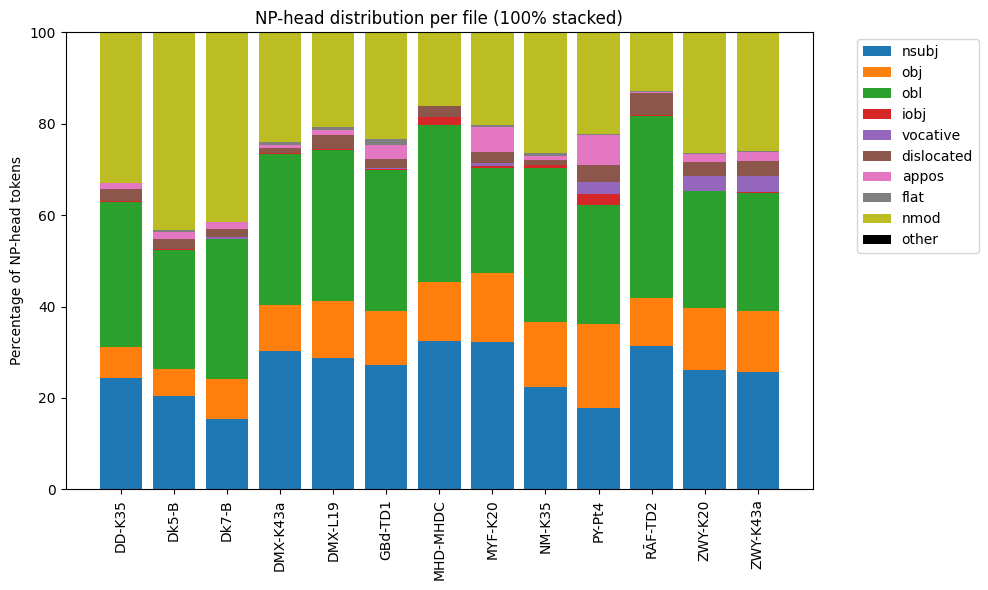

In [7]:
import matplotlib.pyplot as plt
from collections import defaultdict

np_head_deprels = [
    "nsubj", "obj", "obl",
    "iobj", "vocative", "dislocated",
    "appos", "flat", "nmod"
]

def plot_np_head_full_analysis(corpus):

    per_file_counts = defaultdict(lambda: defaultdict(int))
    per_file_np_total = defaultdict(int)
    per_file_token_total = defaultdict(int)

    global_np_total = 0

    # =========================
    # COLLECT DATA
    # =========================
    for sent in corpus:
        f = sent.file_name

        for tok in sent.get_tokens():
            per_file_token_total[f] += 1

            dep = tok.deprel
            if not dep:
                continue

            dep = dep.split("|")[0].strip()
            base = dep.split(":")[0]

            if base.endswith("cl"):
                continue

            if any(dep.startswith(p) for p in np_head_deprels):
                per_file_np_total[f] += 1
                global_np_total += 1

                matched = False
                for p in np_head_deprels:
                    if dep.startswith(p):
                        per_file_counts[f][p] += 1
                        matched = True
                        break

                if not matched:
                    per_file_counts[f]["other"] += 1

    files = list(per_file_counts.keys())

    # =========================
    # FILTER FILES (< 1% corpus contribution)
    # =========================
    files = [
        f for f in files
        if (per_file_np_total[f] / global_np_total * 100) >= 1.0
    ]

    cats = np_head_deprels + ["other"]
    # =========================
    # STACKED % WITHIN FILE
    # =========================
    data = {c: [] for c in cats}

    for f in files:
        total_np = per_file_np_total[f]

        for c in cats:
            val = per_file_counts[f][c]
            data[c].append((val / total_np * 100) if total_np > 0 else 0)

    # =========================
    # PLOT STACKED BAR
    # =========================
    plt.figure(figsize=(10, 6))

    bottom = [0] * len(files)

    colors = [
        "#1f77b4", "#ff7f0e", "#2ca02c",
        "#d62728", "#9467bd", "#8c564b",
        "#e377c2", "#7f7f7f", "#bcbd22",
        "#000000"
    ]

    for i, c in enumerate(cats):
        plt.bar(
            files,
            data[c],
            bottom=bottom,
            label=c,
            color=colors[i]
        )
        bottom = [bottom[j] + data[c][j] for j in range(len(files))]

    plt.title("NP-head distribution per file (100% stacked)")
    plt.xticks(rotation=90)
    plt.ylabel("Percentage of NP-head tokens")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    
    # =========================
    # OPTION 1 FIX: RETURN VALUES
    # =========================
    return per_file_np_total, global_np_total, files

per_file_np_total, global_np_total, files = plot_np_head_full_analysis(annotated_corpus)

In [8]:
print("\n=== FILE SHARE OF TOTAL NP-HEADS IN CORPUS (≥ 1%) ===")

for f in files:
    share = (per_file_np_total[f] / global_np_total * 100) if global_np_total > 0 else 0

    if share < 1.0:
        continue

    print(f"{f:25} | {per_file_np_total[f]:6} NP-heads | {share:6.2f}% of corpus")


=== FILE SHARE OF TOTAL NP-HEADS IN CORPUS (≥ 1%) ===
DD-K35                    |   1498 NP-heads |   6.61% of corpus
Dk5-B                     |   2065 NP-heads |   9.11% of corpus
Dk7-B                     |    849 NP-heads |   3.74% of corpus
DMX-K43a                  |   1066 NP-heads |   4.70% of corpus
DMX-L19                   |    946 NP-heads |   4.17% of corpus
GBd-TD1                   |   7629 NP-heads |  33.65% of corpus
MHD-MHDC                  |   1166 NP-heads |   5.14% of corpus
MYF-K20                   |    544 NP-heads |   2.40% of corpus
NM-K35                    |   1711 NP-heads |   7.55% of corpus
PY-Pt4                    |   1310 NP-heads |   5.78% of corpus
RĀF-TD2                   |    644 NP-heads |   2.84% of corpus
ZWY-K20                   |   1055 NP-heads |   4.65% of corpus
ZWY-K43a                  |   1061 NP-heads |   4.68% of corpus


In [9]:
from collections import defaultdict

np_head_deprels = [
    "nmod", "nsubj", "obj", "obl",
    "iobj", "vocative", "dislocated",
    "appos", "flat"
]

def normalize_deprel(deprel):
    if not deprel:
        return None
    return deprel.split("|")[0].strip()

def is_cl_variant(deprel):
    if not deprel:
        return False
    base = deprel.split(":")[0]
    return base.endswith("cl")

def is_np_head(deprel):
    if not deprel:
        return False
    if is_cl_variant(deprel):
        return False
    return any(deprel.startswith(p) for p in np_head_deprels)


# =========================================================
# UPOS × DEPREL ANALYSIS
# =========================================================

def compute_np_head_upos_distribution(corpus):

    upos_counts = defaultdict(lambda: defaultdict(int))
    global_total = 0

    for sent in corpus:
        for tok in sent.get_tokens():

            dep = normalize_deprel(tok.deprel)

            if not is_np_head(dep):
                continue

            upos = tok.upos if tok.upos else "_"

            # assign to base NP-head category
            matched = False
            for p in np_head_deprels:
                if dep.startswith(p):
                    upos_counts[p][upos] += 1
                    matched = True
                    break

            if not matched:
                upos_counts["other"][upos] += 1

            global_total += 1

    # =========================
    # PRINT RESULTS
    # =========================
    print("\n=== UPOS DISTRIBUTION PER NP-HEAD DEPREL ===")

    for dep in np_head_deprels + ["other"]:
        total = sum(upos_counts[dep].values())
        if total == 0:
            continue

        print(f"\n--- {dep} (total={total}) ---")

        for upos, count in sorted(upos_counts[dep].items()):
            perc = (count / total * 100) if total > 0 else 0
            print(f"{upos:10} | {count:6} | {perc:6.2f}%")

    print(f"\nTOTAL NP-head tokens: {global_total}")


# Run
compute_np_head_upos_distribution(annotated_corpus)


=== UPOS DISTRIBUTION PER NP-HEAD DEPREL ===

--- nmod (total=5958) ---
ADJ        |    126 |   2.11%
ADP        |      1 |   0.02%
ADV        |     10 |   0.17%
DET        |     13 |   0.22%
NOUN       |   3675 |  61.68%
NUM        |     32 |   0.54%
PART       |      1 |   0.02%
PRON       |    919 |  15.42%
PROPN      |   1173 |  19.69%
PUNCT      |      1 |   0.02%
_          |      7 |   0.12%

--- nsubj (total=5751) ---
ADJ        |    118 |   2.05%
ADV        |      4 |   0.07%
DET        |     16 |   0.28%
NOUN       |   3288 |  57.17%
NUM        |    147 |   2.56%
PRON       |   1468 |  25.53%
PROPN      |    681 |  11.84%
SCONJ      |     12 |   0.21%
VERB       |      9 |   0.16%
_          |      8 |   0.14%

--- obj (total=2659) ---
ADJ        |     48 |   1.81%
ADP        |      1 |   0.04%
ADV        |      4 |   0.15%
DET        |     30 |   1.13%
NOUN       |   2061 |  77.51%
NUM        |     19 |   0.71%
PRON       |    342 |  12.86%
PROPN      |    151 |   5.68%
_  

In [10]:
def find_deprel_upos_instances(corpus, target_deprel, target_upos):

    matches = []

    for sent in corpus:

        sent_id = sent.metadata.get("sent_id", "_")
        text = sent.metadata.get("text", "_")
        file_name = sent.file_name

        for tok in sent.get_tokens():

            dep = tok.deprel
            upos = tok.upos if tok.upos else "_"

            if not dep:
                continue

            dep = dep.split("|")[0].strip()

            # normalize cl variants (same logic as before)
            base = dep.split(":")[0]
            if base.endswith("cl"):
                continue

            # =========================
            # MATCH CONDITION
            # =========================
            if dep.startswith(target_deprel) and upos == target_upos:

                print(
                    f"{sent_id}: {text} | "
                    f"{tok.form} ({tok.lemma}) | "
                    f"UPOS={upos}, DEPREL={dep} | "
                    f"{file_name}"
                )

                matches.append({
                    "sent_id": sent_id,
                    "text": text,
                    "token": tok.form,
                    "lemma": tok.lemma,
                    "upos": upos,
                    "deprel": dep,
                    "file": file_name
                })

    print(f"\nTotal matches: {len(matches)}")
    return matches


# =========================
# EXAMPLE USAGE
# =========================

find_deprel_upos_instances(
    annotated_corpus,
    target_deprel="nmod",
    target_upos="ADV"
)

85: ud druwandān pad yōǰdāsrēnīdārīh az wināh āhōg ǰud ǰud wināh ī kird ud gumēzišn ī awiš passazag ačārīg pādifrāh ī az yōǰdāsrgarān abar rasēd | awiš (awiš) | UPOS=ADV, DEPREL=nmod | Dk5-B
365: kē zāyišn ī dēwān škeft sahēd fradom čiyōnīh nigerišn ī kadāmagāniz zāyišn kū mādayān abzāyišn ī az gyāg tā ēn kū dēwān harrōbišn ō ānōh wēš kū adādīhā ud anēwēnīh mehmāntar hupaydāg | ānōh (ānōh) | UPOS=ADV, DEPREL=nmod | Dk5-B
6: ud rawāgīh fradom mēnōyīhā andar amahraspandān abārīg yazdān mēnōyān yazdān , ud gētīyīhā andar gayōmard ī fradom mard pad hangirdīg bowandag padīriftārīh ī az dādār ohrmazd | mēnōyīhā (mēnōyīhā) | UPOS=ADV, DEPREL=nmod | Dk7-B
81: ud pad harw kas padiš wistāx būdan awestwārīh weh , | padiš (padiš) | UPOS=ADV, DEPREL=nmod | DMX-K43a
1288: ān ī čagarīhā ōwōn čiyōn ān ī pādixšāyīhā ayāb ǰuttar | čagarīhā (čagarīhā) | UPOS=ADV, DEPREL=nmod | MHD-MHDC
140: ēdōn saham kū nē frēstēnišn ī abar ōwōn rāh X bē samēnišn ēw ī yōǰdāsrgarān ōwōn nibišt kū tā ham sam rāy abērtar š

[{'sent_id': '85',
  'text': 'ud druwandān pad yōǰdāsrēnīdārīh az wināh āhōg ǰud ǰud wināh ī kird ud gumēzišn ī awiš passazag ačārīg pādifrāh ī az yōǰdāsrgarān abar rasēd',
  'token': 'awiš',
  'lemma': 'awiš',
  'upos': 'ADV',
  'deprel': 'nmod',
  'file': 'Dk5-B'},
 {'sent_id': '365',
  'text': 'kē zāyišn ī dēwān škeft sahēd fradom čiyōnīh nigerišn ī kadāmagāniz zāyišn kū mādayān abzāyišn ī az gyāg tā ēn kū dēwān harrōbišn ō ānōh wēš kū adādīhā ud anēwēnīh mehmāntar hupaydāg',
  'token': 'ānōh',
  'lemma': 'ānōh',
  'upos': 'ADV',
  'deprel': 'nmod',
  'file': 'Dk5-B'},
 {'sent_id': '6',
  'text': 'ud rawāgīh fradom mēnōyīhā andar amahraspandān abārīg yazdān mēnōyān yazdān , ud gētīyīhā andar gayōmard ī fradom mard pad hangirdīg bowandag padīriftārīh ī az dādār ohrmazd',
  'token': 'mēnōyīhā',
  'lemma': 'mēnōyīhā',
  'upos': 'ADV',
  'deprel': 'nmod',
  'file': 'Dk7-B'},
 {'sent_id': '81',
  'text': 'ud pad harw kas padiš wistāx būdan awestwārīh weh ,',
  'token': 'padiš',
  'lemma'

In [11]:
def find_deprel_sentences(corpus, target_deprel, prefix_match=True):
    count = 0

    for sent in corpus:
        for tok in sent.get_tokens():
            dep = tok.deprel or ""

            match = (
                dep.startswith(target_deprel)
                if prefix_match
                else dep == target_deprel
            )

            if match:
                count += 1

                print(
                    f"{sent.sentence_id}: {sent.text} | "
                    f"TOKEN='{tok.form}' | "
                    f"DEPREL='{tok.deprel}' | "
                    f"HEAD={tok.head} | "
                    f"source={sent.file_name}"
                )

    print(f"\nTotal matches for '{target_deprel}': {count}")

# Example usage:
find_deprel_sentences(annotated_corpus, "obl|orphan", prefix_match=True)    

1646: čē čiyōn āb pad ān paymānag ī =m guft kū abāz ō xān rasēd āfrīn =iz ī dahmān kunēnd pad ān paymānag abāz ō mard rasēd | TOKEN='paymānag' | DEPREL='obl|orphan' | HEAD=14 | source=GBd-TD1

Total matches for 'obl|orphan': 1
